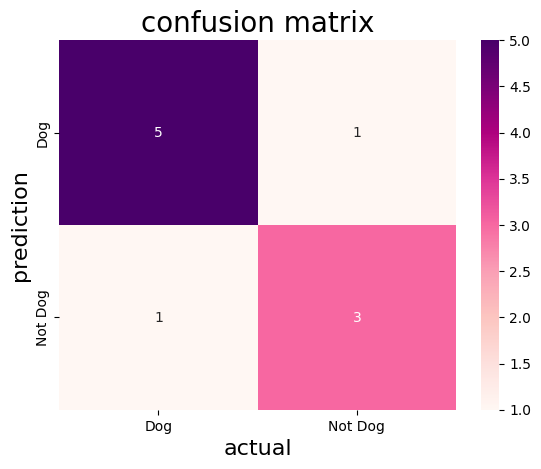

In [1]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
actual = np.array(
['Dog','Dog','Dog','Not Dog','Dog','Not Dog','Dog','Dog','Not Dog','Not Dog'])
predicted = np.array(
['Dog','Not Dog','Dog','Not Dog','Dog','Dog','Dog','Dog','Not Dog','Not Dog'])
conf_matrix=confusion_matrix(actual,predicted)
sns.heatmap(conf_matrix,annot=True,fmt='g',xticklabels=['Dog','Not Dog'],yticklabels=['Dog','Not Dog'],cmap='RdPu')
plt.ylabel("prediction",fontsize=16)
plt.xlabel("actual",fontsize=16)
plt.title("confusion matrix",fontsize=20)
plt.show()

accuracy: 0.9743589743589743
Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        17
     class_1       0.96      1.00      0.98        22

    accuracy                           0.97        39
   macro avg       0.98      0.97      0.97        39
weighted avg       0.98      0.97      0.97        39

Precision: 0.96
Recall: 1.00
F1 Score: 0.98


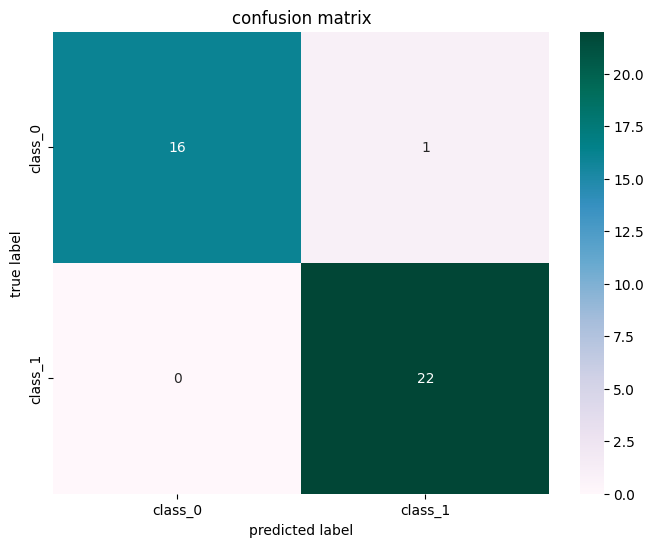

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,classification_report,confusion_matrix
wine=load_wine()
data=pd.DataFrame(data=wine.data,columns=wine.feature_names)
data['Target']=wine.target
data=data[data['Target']!=2]
x=data.drop('Target',axis=1)

y=data['Target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
model=DecisionTreeClassifier(random_state=1)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
class_report = classification_report(y_test, y_pred,
target_names=wine.target_names[:2])
print("Classification Report:\n", class_report)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
conf_matrix=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='PuBuGn',xticklabels=wine.
target_names[:2],yticklabels=wine.target_names[:2])
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.title("confusion matrix")
plt.show()

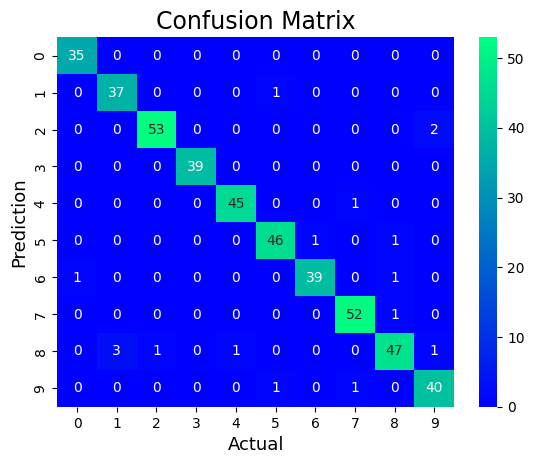

Accuracy : 0.9622222222222222


In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
X, y= load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25)
clf = RandomForestClassifier(random_state=23)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,
annot=True,
fmt='g',cmap="winter")
plt.ylabel('Prediction',fontsize=13)
plt.xlabel('Actual',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

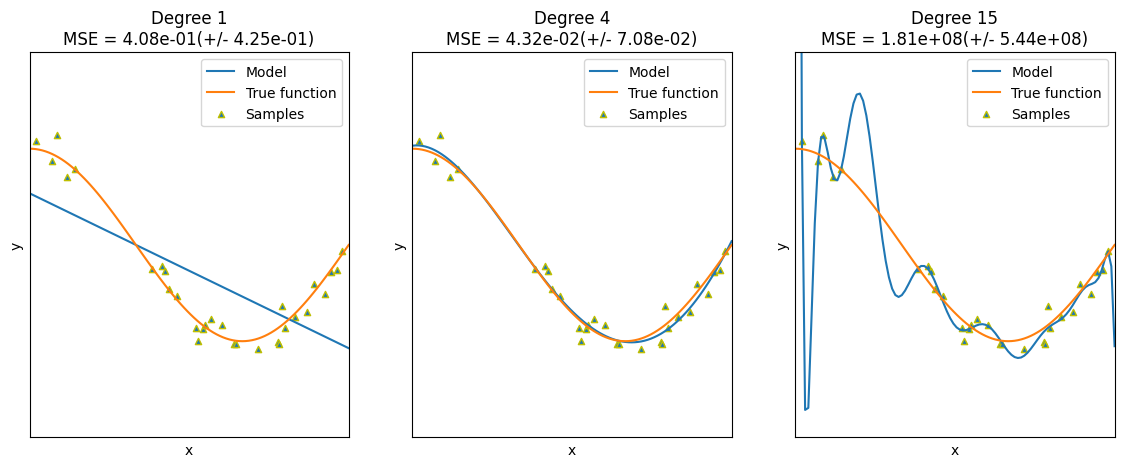

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)

n_samples = 30
degrees = [1, 4, 15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i],
                                             include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ("polynomial_features", polynomial_features),
            ("linear_regression", linear_regression),
        ]
    )
    pipeline.fit(X[:, np.newaxis], y)
    scores = cross_val_score(
        pipeline, X[:, np.newaxis], y, scoring="neg_mean_squared_error", cv=10
    )

    X_test = np.linspace(0, 1, 100)

    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), label="True function")
    plt.scatter(X, y, edgecolor="y", s=20,marker="^", label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title(
        """Degree {}
MSE = {:.2e}(+/- {:.2e})""".format(
            degrees[i], -scores.mean(), scores.std()
        )
    )
plt.show()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
Mean Squared Error on test set: 0.23


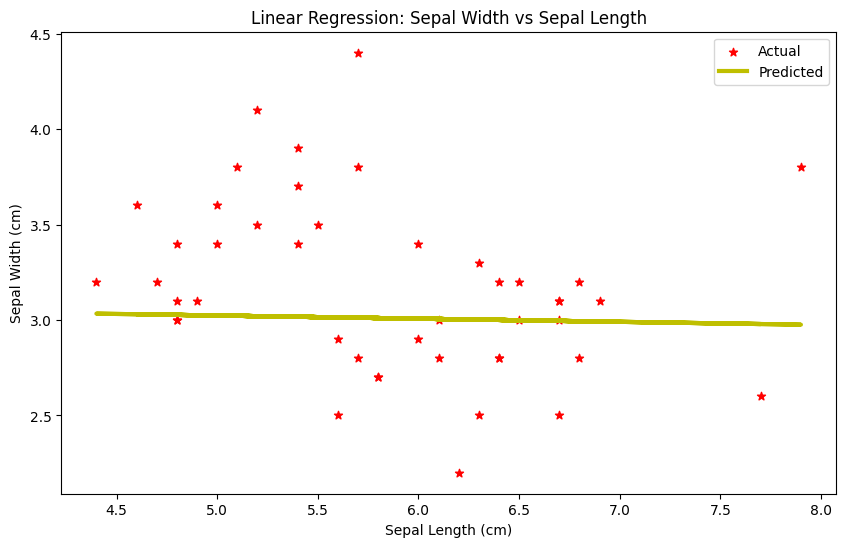

The predicted sepal width for sepal length [[5]]
is 3.02 cm


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target
print(data.head())
X = data[['sepal length (cm)']]
y = data['sepal width (cm)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error on test set: {mse:.2f}')
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='r',marker='*', label='Actual')
plt.plot(X_test, y_pred, color='y', linewidth=3, label='Predicted')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Linear Regression: Sepal Width vs Sepal Length')
plt.legend()
plt.show()

new_sample = pd.DataFrame([[5]], columns=['sepal length (cm)'])
predicted_width = model.predict(new_sample)
print(f"""The predicted sepal width for sepal length {new_sample.values.tolist()}
is {predicted_width[0]:.2f} cm""")

accuracy: 0.7037037037037037


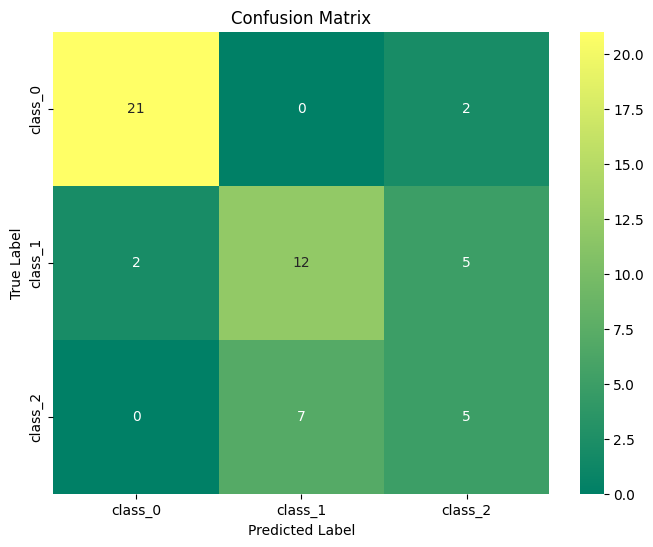

In [11]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
wine=load_wine()
data=pd.DataFrame(data=wine.data,columns=wine.feature_names)
data['Target']=wine.target
x=data.drop('Target',axis=1)
y=data['Target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='summer',
xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

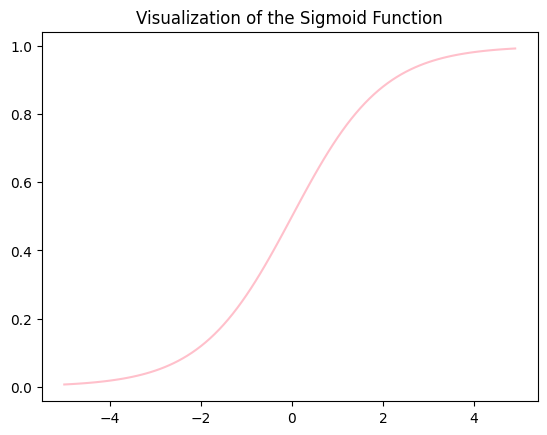

In [13]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(z):
    return 1 / (1 + np.exp( - z))
plt.plot(np.arange(-5, 5, 0.1), sigmoid(np.arange(-5, 5, 0.1)),color='pink')
plt.title('Visualization of the Sigmoid Function')
plt.show()

accuracy: 0.9777777777777777


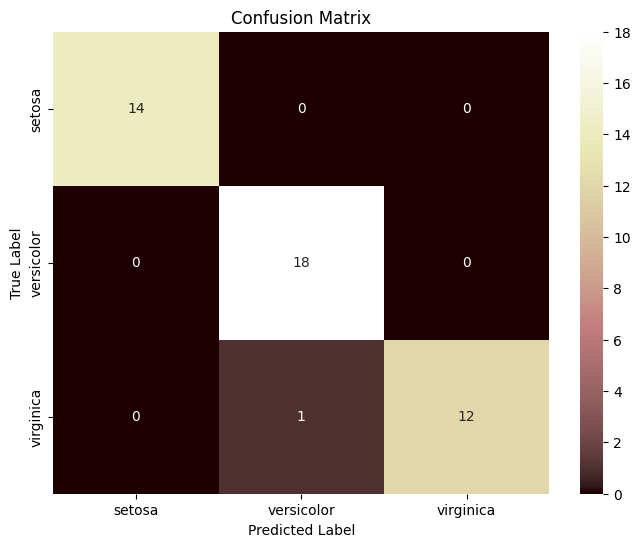

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
iris=load_iris()
data=pd.DataFrame(data=iris.data,columns=iris.feature_names)
data['Species']=iris.target
x=data.drop('Species',axis=1)
y=data['Species']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='pink',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

accuracy: 0.9777777777777777


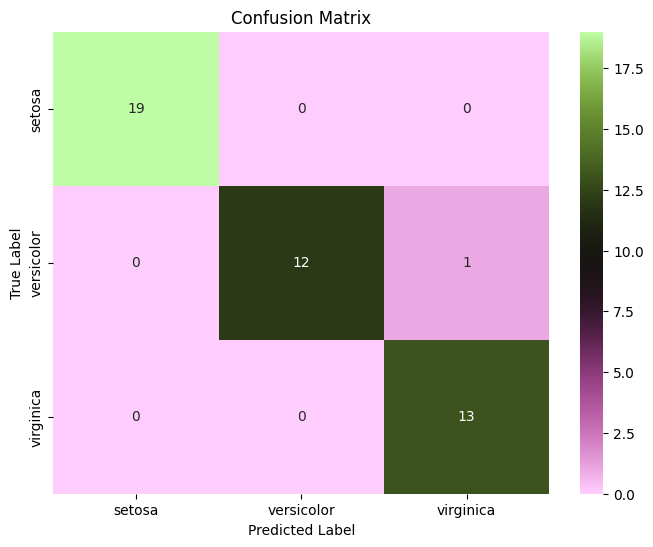

In [15]:
#naive bayes iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix
iris = load_iris()

data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target
X = data.drop('species', axis=1)
y = data['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='vanimo',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

accuracy: 0.9666666666666667


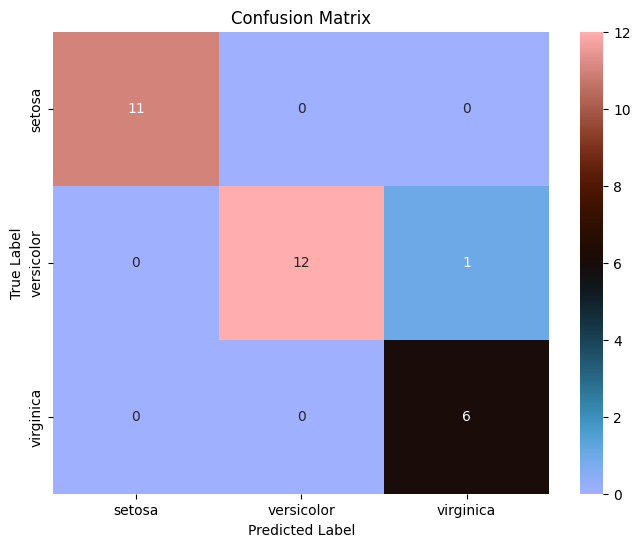

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)

data['species'] = iris.target
X = data.drop('species', axis=1)
y = data['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=1)
model =LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("accuracy:",accuracy)
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='berlin',
xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()